Train shape: (55724, 24, 13)
Test shape: (13932, 24, 13)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 24, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 24, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer (Attention)     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,241 (102.50 KB)

 Trainable params: 26,241 (102.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0155 - val_loss: 0.0087
Epoch 2/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0053 - val_loss: 0.0066
Epoch 3/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0040 - val_loss: 0.0093
Epoch 4/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0034 - val_loss: 0.0062
Epoch 5/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0032 - val_loss: 0.0064
Epoch 6/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0031 - val_loss: 0.0055
Epoch 7/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0030 - val_loss: 0.0070
Epoch 8/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.0029 - val_loss: 0.0066
Epoch 9/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0029 - val_loss: 0.0077
Epoch 10/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0027 - val_loss: 0.0078
Epoch 11/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0027 - val_loss: 0.0077
Epoch 12/20
784/784 ━━━━━━━━━━

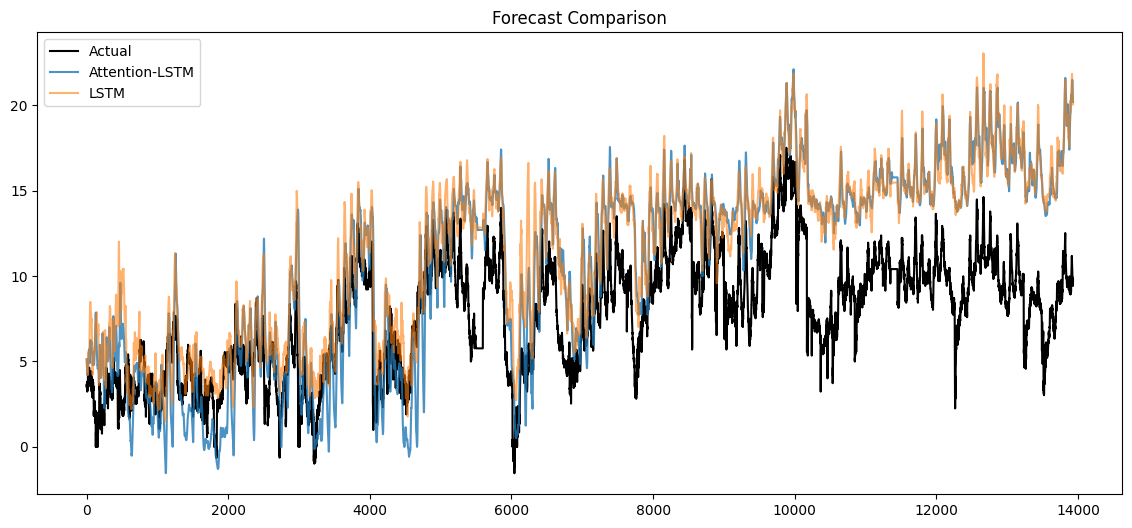

Using LSTM layer: encoder_lstm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Hidden state shape: (1, 24, 64)
Attention weight shape: (24, 64)


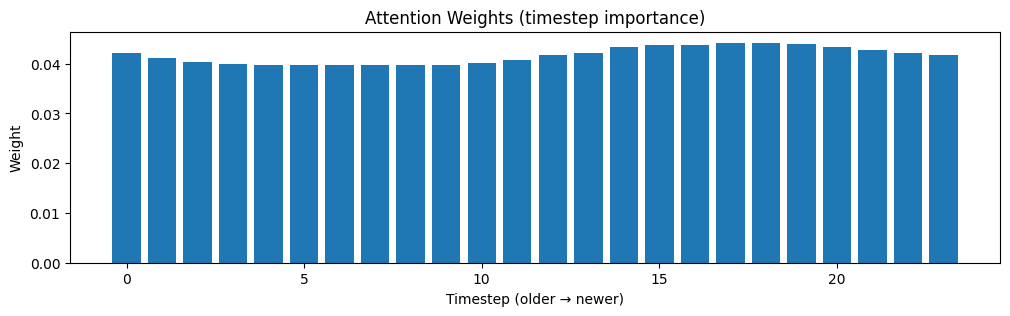

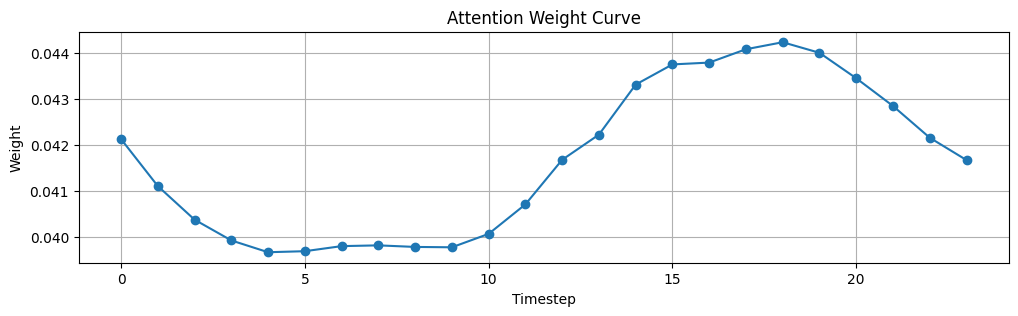


All steps completed successfully!


In [ ]:


import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load & Preprocess Dataset
# -----------------------------

df = pd.read_csv("ETTm.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.dropna()

# Features = all except date, OT
features = df.drop(["date", "OT"], axis=1)
target = df["OT"].values.reshape(-1, 1)

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
features_scaled = scaler_X.fit_transform(features)
target_scaled = scaler_y.fit_transform(target)

# Create supervised sequences
def create_sequences(X, y, timesteps=24):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])
    return np.array(Xs), np.array(ys)

TIMESTEPS = 24
X, y = create_sequences(features_scaled, target_scaled, TIMESTEPS)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# 2. Custom Attention Layer
# -----------------------------

class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.last_att_weights = None

    def build(self, input_shape):
        dim = input_shape[-1]
        self.W = self.add_weight(shape=(dim, dim),
                                 initializer="random_normal",
                                 trainable=True)
        self.b = self.add_weight(shape=(dim,),
                                 initializer="zeros",
                                 trainable=True)

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * inputs
        context_vector = tf.reduce_sum(context, axis=1)

        # Save weights for extraction
        self.last_att_weights = attention_weights
        return context_vector

    def get_attention_weights(self):
        return self.last_att_weights

# -----------------------------
# 3. Build Models
# -----------------------------

def build_attention_lstm(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(64, return_sequences=True, name="encoder_lstm")(inputs)
    x = Attention(name="attention_layer")(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(loss="mse", optimizer="adam")
    return model

def build_lstm(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(64)(inputs)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(loss="mse", optimizer="adam")
    return model

attention_model = build_attention_lstm(X_train.shape[1:])
lstm_model = build_lstm(X_train.shape[1:])

attention_model.summary()

# -----------------------------
# 4. Train Models
# -----------------------------

history_att = attention_model.fit(
    X_train, y_train, epochs=20, batch_size=64,
    validation_split=0.1, verbose=1)

history_lstm = lstm_model.fit(
    X_train, y_train, epochs=20, batch_size=64,
    validation_split=0.1, verbose=1)

# -----------------------------
# 5. Evaluate and Compare
# -----------------------------

y_pred_att = attention_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)

y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_att_inv = scaler_y.inverse_transform(y_pred_att)
y_pred_lstm_inv = scaler_y.inverse_transform(y_pred_lstm)

def get_metrics(true, pred):
    return {
        "MSE": mean_squared_error(true, pred),
        "MAE": mean_absolute_error(true, pred)
    }

print("Attention LSTM:", get_metrics(y_test_inv, y_pred_att_inv))
print("Vanilla LSTM:", get_metrics(y_test_inv, y_pred_lstm_inv))

plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label="Actual", color="black")
plt.plot(y_pred_att_inv, label="Attention-LSTM", alpha=0.8)
plt.plot(y_pred_lstm_inv, label="LSTM", alpha=0.6)
plt.legend()
plt.title("Forecast Comparison")
plt.show()

# =====================================================
# 6. Extract LSTM hidden states and Attention Weights
# =====================================================

# --- Find LSTM layer robustly (no name needed) ---
lstm_layer = None
for layer in attention_model.layers:
    if isinstance(layer, tf.keras.layers.LSTM):
        if layer.get_config().get("return_sequences", False):
            lstm_layer = layer
            break

if lstm_layer is None:
    raise RuntimeError("No return_sequences LSTM found!")

print("Using LSTM layer:", lstm_layer.name)

# --- Build intermediate model to extract hidden states ---
intermediate_model = tf.keras.Model(
    inputs=attention_model.input,
    outputs=lstm_layer.output
)

# Extract hidden states for 1 test sample
hidden_states = intermediate_model.predict(X_test[:1])
print("Hidden state shape:", hidden_states.shape)  # (1, 24, 64)

# --- Extract Attention Layer ---
att_layer = None
for layer in attention_model.layers:
    if isinstance(layer, Attention):
        att_layer = layer
        break

_ = att_layer(hidden_states)   # forward pass
weights = att_layer.get_attention_weights().numpy().squeeze()
print("Attention weight shape:", weights.shape)  # (24, 64)

# Reduce across feature dimension → timestep importance
weights_mean = np.mean(weights, axis=1)

# -----------------------------
# 7. Plot Attention Weights
# -----------------------------

plt.figure(figsize=(12, 3))
plt.bar(range(len(weights_mean)), weights_mean)
plt.title("Attention Weights (timestep importance)")
plt.xlabel("Timestep (older → newer)")
plt.ylabel("Weight")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(weights_mean, marker="o")
plt.title("Attention Weight Curve")
plt.xlabel("Timestep")
plt.ylabel("Weight")
plt.grid(True)
plt.show()

print("\nAll steps completed successfully!")
